# 05 - Tournament

Five evaluators play a round-robin: each ordered (white, black) pair plays one game at fixed search depth. The search and move generator are identical for all of them, so any difference in tournament scores is down to the weight vector $\mathbf{w}$.

The five players:

| name                  | weights                                              |
|-----------------------|------------------------------------------------------|
| `random`              | tiny random weights, picks essentially random moves  |
| `material_only`       | only the 5 material weights are nonzero              |
| `psqt_handcrafted`    | material + PeSTO PSQT, hand-crafted                  |
| `learned_LS`          | weights from notebook 04, least-squares fit          |
| `learned_logistic`    | weights from notebook 04, Texel-tuned                |

Expected ordering: `random` should be last; `material_only` < `psqt_handcrafted`; the learned ones somewhere comparable to `psqt_handcrafted`.

In [10]:
import os
import sys
import time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import chess
import chess.engine
import chess.svg
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, display
from tqdm.auto import tqdm

from chess_engine.evaluate import Evaluator
from chess_engine.features import N_FEATURES
from chess_engine.selfplay import play_game

DATA_DIR = Path('..') / 'data'
GAMES_DIR = DATA_DIR / 'games'
GAMES_DIR.mkdir(exist_ok=True)

## Build the player pool

Notebook 04 needs to have run first so the learned weight files exist.

In [11]:
rng = np.random.default_rng(42)
random_weights = rng.normal(scale=0.05, size=N_FEATURES).astype(np.float32)

players = [
    Evaluator(random_weights, name='random'),
    Evaluator.material_only(),
    Evaluator.psqt_handcrafted(),
]

for fname, label in [('weights_ls.npy',       'learned_LS'),
                     ('weights_logistic.npy', 'learned_logistic')]:
    path = DATA_DIR / fname
    if path.exists():
        players.append(Evaluator(np.load(path), name=label))
    else:
        print(f'WARNING: {path} missing; run notebook 04 first to include {label}.')

print('player pool:')
for p in players:
    print(f'   - {p.name}')

player pool:
   - random
   - material_only
   - psqt_handcrafted
   - learned_LS
   - learned_logistic


## Round-robin

Each ordered pair plays one game at depth 2, capped at 120 plies (60 moves) so a stuck shuffler doesn't loop forever. Save every PGN under `data/games/`.

In [12]:
DEPTH = 2
MAX_PLIES = 120

RESULT_TO_WHITE_SCORE = {'1-0': 1.0, '0-1': 0.0, '1/2-1/2': 0.5, '*': 0.5}
n_players = len(players)
S = np.full((n_players, n_players), np.nan)

pairings = [(i, j) for i in range(n_players) for j in range(n_players) if i != j]
t0 = time.perf_counter()
for i, j in tqdm(pairings, desc='games'):
    white, black = players[i], players[j]
    game = play_game(white, black, depth=DEPTH, max_plies=MAX_PLIES)
    res = game.headers.get('Result', '*')
    S[i, j] = RESULT_TO_WHITE_SCORE[res]
    pgn_path = GAMES_DIR / f'{i}_{white.name}__vs__{j}_{black.name}.pgn'
    pgn_path.write_text(str(game) + '\n', encoding='utf-8')
elapsed = time.perf_counter() - t0
print(f'finished {len(pairings)} games in {elapsed:.1f}s ({elapsed/len(pairings):.2f}s/game)')

games:   0%|          | 0/20 [00:00<?, ?it/s]

finished 20 games in 12.9s (0.64s/game)


## Results

Sum points won as white (the row of $S$) plus points won as black ($1$ minus the column):

$$\text{total}_i = \sum_{j \neq i} S_{ij} + \sum_{j \neq i} (1 - S_{ji}).$$

Each player plays $2(n-1)$ games, so the max possible score is $2(n-1)$.

In [13]:
def total_score(S):
    n = S.shape[0]
    out = np.zeros(n)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            out[i] += S[i, j]
            out[i] += 1 - S[j, i]
    return out

scores = total_score(S)
max_score = 2 * (n_players - 1)
names = [p.name for p in players]

ranking = np.argsort(-scores)
print(f'standings (max possible: {max_score}):')
for rank, idx in enumerate(ranking, 1):
    print(f'  {rank}. {names[idx]:20s}  {scores[idx]:5.1f} / {max_score}')

standings (max possible: 8):
  1. psqt_handcrafted        6.0 / 8
  2. learned_LS              4.5 / 8
  3. material_only           3.5 / 8
  4. learned_logistic        3.5 / 8
  5. random                  2.5 / 8


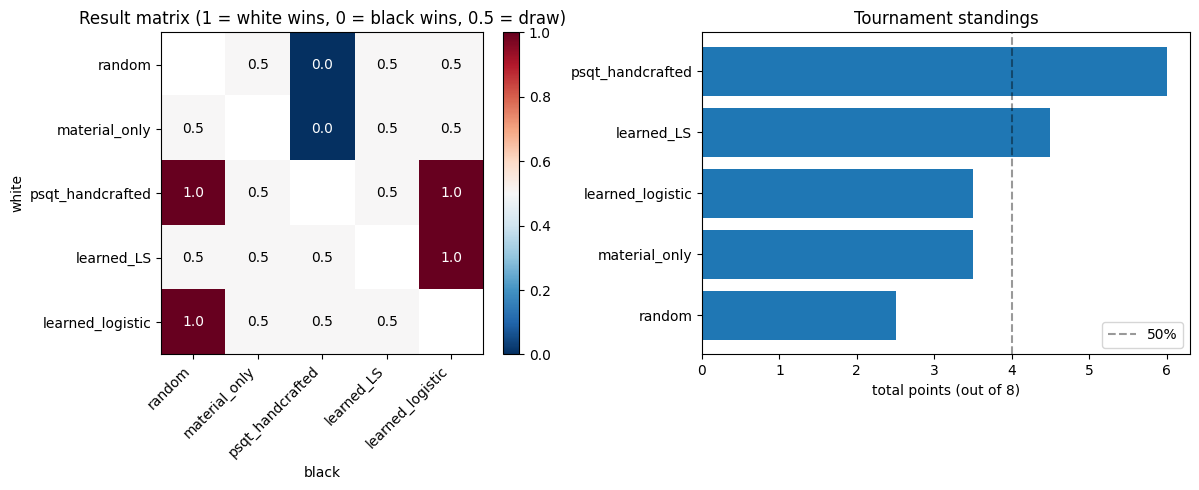

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(S, cmap='RdBu_r', vmin=0, vmax=1)
axes[0].set_xticks(range(n_players), names, rotation=45, ha='right')
axes[0].set_yticks(range(n_players), names)
axes[0].set_xlabel('black')
axes[0].set_ylabel('white')
axes[0].set_title('Result matrix (1 = white wins, 0 = black wins, 0.5 = draw)')
for i in range(n_players):
    for j in range(n_players):
        if not np.isnan(S[i, j]):
            axes[0].text(j, i, f'{S[i, j]:.1f}', ha='center', va='center',
                         color='white' if abs(S[i, j] - 0.5) > 0.3 else 'black')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

order = np.argsort(scores)
axes[1].barh(np.arange(n_players), scores[order], color='#1f77b4')
axes[1].set_yticks(np.arange(n_players), [names[i] for i in order])
axes[1].set_xlabel(f'total points (out of {max_score})')
axes[1].set_title('Tournament standings')
axes[1].axvline(max_score / 2, color='k', ls='--', alpha=0.4, label='50%')
axes[1].legend()
plt.tight_layout(); plt.show()

## Versus Stockfish (optional)

If Stockfish is on PATH or `STOCKFISH_PATH` points to it, the best learned evaluator plays one game as white and one as black at low skill levels. Wrapped in try/except so the cell doesn't fail if Stockfish isn't installed.

In [15]:
import shutil

_STOCKFISH_NAMES = (
    'stockfish', 'stockfish-windows-x86-64-avx2',
    'stockfish-windows-x86-64-bmi2', 'stockfish-windows-x86-64',
    'stockfish-ubuntu-x86-64-avx2', 'stockfish-macos-arm64-apple-silicon',
)

def find_stockfish():
    p = os.environ.get('STOCKFISH_PATH')
    if p and Path(p).exists():
        return p
    for name in _STOCKFISH_NAMES:
        found = shutil.which(name)
        if found:
            return found
    return None

STOCKFISH_PATH = find_stockfish()
print(f'stockfish: {STOCKFISH_PATH}')

stockfish: C:\Users\rozsa\AppData\Local\Microsoft\WinGet\Packages\Stockfish.Stockfish_Microsoft.Winget.Source_8wekyb3d8bbwe\stockfish\stockfish-windows-x86-64-avx2.exe


In [16]:
def play_vs_stockfish(our_eval, our_color, sf_path, sf_skill=0, sf_nodes=200, depth=2, max_plies=120):
    import chess.pgn
    from chess_engine.search import search_best_move

    board = chess.Board()
    game = chess.pgn.Game()
    sf_label = f'Stockfish (skill={sf_skill}, nodes={sf_nodes})'
    game.headers['White'] = our_eval.name if our_color == chess.WHITE else sf_label
    game.headers['Black'] = our_eval.name if our_color == chess.BLACK else sf_label
    node = game

    with chess.engine.SimpleEngine.popen_uci(sf_path) as sf:
        sf.configure({'Skill Level': sf_skill})
        for _ in range(max_plies):
            if board.is_game_over(claim_draw=True):
                break
            if board.turn == our_color:
                move = search_best_move(board, depth, our_eval).move
            else:
                move = sf.play(board, chess.engine.Limit(nodes=sf_nodes)).move
            if move is None:
                break
            board.push(move)
            node = node.add_variation(move)
    game.headers['Result'] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else '1/2-1/2'
    return game

In [19]:
if STOCKFISH_PATH is None:
    print('Skipping Stockfish match - set STOCKFISH_PATH to enable.')
else:
    our = next((p for p in players if p.name == 'learned_logistic'), None) \
          or next((p for p in players if p.name == 'learned_LS'), None) \
          or next(p for p in players if p.name == 'psqt_handcrafted')
    print(f'Playing {our.name} vs Stockfish (skill 0, 200 nodes)...')
    try:
        g_white = play_vs_stockfish(our, chess.WHITE, STOCKFISH_PATH)
        g_black = play_vs_stockfish(our, chess.BLACK, STOCKFISH_PATH)
        print(f'  as white: {g_white.headers["Result"]}')
        print(f'  as black: {g_black.headers["Result"]}')
        (GAMES_DIR / f'{our.name}_vs_stockfish_white.pgn').write_text(str(g_white) + '\n', encoding='utf-8')
        (GAMES_DIR / f'{our.name}_vs_stockfish_black.pgn').write_text(str(g_black) + '\n', encoding='utf-8')
    except Exception as e:
        print(f'  Stockfish match failed: {e}')

Playing learned_logistic vs Stockfish (skill 0, 200 nodes)...
  Stockfish match failed: 


## A representative game

Pick the longest decisive game from the round-robin and render its final position.

Longest decisive game (79 plies): 4_learned_logistic__vs__0_random
  learned_logistic (W)  vs  random (B)  ->  1-0


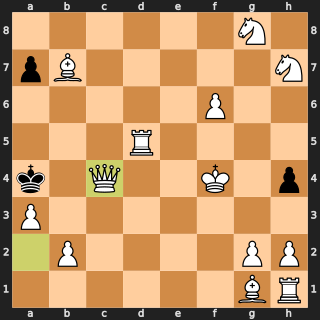


All decisive games this tournament:
   79 plies  1-0      4_learned_logistic__vs__0_random
   66 plies  0-1      1_material_only__vs__2_psqt_handcrafted
   66 plies  0-1      0_random__vs__2_psqt_handcrafted
   65 plies  1-0      2_psqt_handcrafted__vs__0_random
   49 plies  1-0      3_learned_LS__vs__4_learned_logistic
   29 plies  1-0      2_psqt_handcrafted__vs__4_learned_logistic


In [18]:
import chess.pgn

decisive = []
for pgn_file in sorted(GAMES_DIR.glob('*__vs__*.pgn')):
    with pgn_file.open(encoding='utf-8') as f:
        g = chess.pgn.read_game(f)
    if g is None: continue
    res = g.headers.get('Result', '*')
    if res not in ('1-0', '0-1'): continue
    moves = list(g.mainline_moves())
    decisive.append((len(moves), pgn_file.stem, g, moves))

if not decisive:
    print('No decisive games this tournament - every pairing drew.')
else:
    decisive.sort(reverse=True)
    n_plies, stem, g, moves = decisive[0]
    print(f'Longest decisive game ({n_plies} plies): {stem}')
    print(f'  {g.headers["White"]} (W)  vs  {g.headers["Black"]} (B)  ->  {g.headers["Result"]}')

    board = g.board()
    for m in moves:
        board.push(m)
    display(SVG(chess.svg.board(board, size=320,
                                lastmove=moves[-1] if moves else None)))

    print()
    print('All decisive games this tournament:')
    for n_plies, stem, g, _ in sorted(decisive, key=lambda t: -t[0]):
        print(f'  {n_plies:3d} plies  {g.headers["Result"]:7s}  {stem}')